In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import re

# *Data exploration*

In [2]:
df = pd.read_csv('DF_NER.csv')
df[["LIBEQUAL","SECTEUR_ACTIVITE","PROFESSION","PRODUIT","BRANCHE"]].head()

,LIBEQUAL,SECTEUR_ACTIVITE,PROFESSION,PRODUIT,BRANCHE
0,Mr,Services,Sans Précision,Automobile Particulier,AUTO
1,Mr,Sans précision,Sans Précision,R.C Voiturier,DAT
2,Mr,Sans précision,Sans Précision,Automobile Particulier,AUTO
3,Mr,Sans précision,Sans Précision,Catastrophes naturelles - Immobiliers (R.S),DRPP
4,Mr,Services,Fonctionnaire,Automobile Particulier,AUTO


In [65]:
print(df['LIBEQUAL'].unique())

['Mr' 'Organisme' 'Mme' 'Melle' 'SARL' 'Propriétaire' 'Association' 'Sté'
 'SPA' 'EURL' 'Et.' 'Locataire' 'Copropriétaire' 'EPE' 'EPIC' 'APC'
 'HERITIERS' 'ETABLISSEMENT' 'MAITRE' 'Inconnu_oran' 'E.T.B' nan
 'Companie étrangère' 'Companie Mixte']


In [66]:
df.rename(columns={"RAISSOCI": "ENTITY_NAME",
                   "LIBEQUAL": "ENTITY_TYPE"}, inplace=True)

In [ ]:
# affichage de quelques exemples
df[
    (df["ENTITY_TYPE"] == "SARL")
    | (df["ENTITY_TYPE"] == "EURL")
    | (df["ENTITY_TYPE"] == "Mr") | (df["ENTITY_TYPE"] == "Mme")
][["ENTITY_NAME", "ENTITY_TYPE"]].groupby("ENTITY_TYPE").sample(3)

In [69]:
print(df.columns)
df.info()

Index(['ENTITY_NAME', 'ENTITY_TYPE', 'SECTEUR_ACTIVITE', 'PROFESSION',
       'PRODUIT', 'BRANCHE'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3143698 entries, 0 to 3143697
Data columns (total 6 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   ENTITY_NAME       object
 1   ENTITY_TYPE       object
 2   SECTEUR_ACTIVITE  object
 3   PROFESSION        object
 4   PRODUIT           object
 5   BRANCHE           object
dtypes: object(6)
memory usage: 143.9+ MB


# *Data Manipulation*

In [ ]:
# on va creer un nv dataframe où j'aurais entity_name et class, les class on va mettre particulier pour entity_type Mr et Mme, entreprise pour entity_type SARL, EURL
def map_entity_type(entity_type):
    if entity_type in ["Mr", "Mme"]:
        return "Particulier"
    elif entity_type in ["SARL", "EURL"]:
        return "Entreprise"
    else:
        return "Autre"
df["CLASS"] = df["ENTITY_TYPE"].apply(map_entity_type)
#df.sample(10)


In [83]:
df["CLASS"].value_counts()

CLASS
Particulier    2973331
Autre           128465
Entreprise       41902
Name: count, dtype: int64

In [ ]:

entreprise = df[df["CLASS"] == "Entreprise"]
particulier = df[df["CLASS"] == "Particulier"]


# Créer df1 et mélanger (shuffle)
df1 = pd.concat([entreprise.sample(n=min(40000, len(entreprise)), random_state=42),
                 particulier.sample(n=min(60000, len(particulier)), random_state=42)],
                axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

df1.head()

In [100]:
df1 = df1[["ENTITY_NAME","ENTITY_TYPE", "CLASS"]]


In [ ]:
df1[df1["ENTITY_TYPE"]=="EURL"].sample(10)

In [105]:
df1.shape

(100000, 3)

In [106]:
df1.drop_duplicates(inplace=True)
df1.shape

(90329, 3)

In [107]:
df1["CLASS"].value_counts()

CLASS
Particulier    59352
Entreprise     30977
Name: count, dtype: int64

Enlever les mots EURL, SARL, Mr, Mme pour eviter le **data leakage**

d'abord on clean 

In [ ]:

df1["ENTITY_NAME"] = df1["ENTITY_NAME"].str.upper()
df1["ENTITY_NAME"] = df1["ENTITY_NAME"].str.replace(r'[^A-Z0-9\s]', ' ', regex=True)
df1["ENTITY_NAME"] = df1["ENTITY_NAME"].str.strip()


In [ ]:

def clean_name(name):
    if pd.isna(name):
        return ""
        
    # Liste des mots à supprimer pour obliger le modèle à réfléchir
    words_to_remove = [r'\bSARL\b', r'\bEURL\b', r'\bMR\b', r'\bMME\b', r'\bMONSIEUR\b', r'\bMADAME\b']
    
    # Supprimer les mots
    for word in words_to_remove:
        name = re.sub(word, '', name)
    
    return name

# Appliquer le nettoyage
df1["ENTITY_NAME"] = df1["ENTITY_NAME"].apply(clean_name)

**on enleve les mots clés sarl, eurl ...etc pour éviter la mémorisation et favoriser la géneralisation**

In [124]:
df1.to_csv('DF_CLEAN.csv', index=False)

# Data Modeling

## Préprocessing

In [36]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,MaxPooling1D, Conv1D, GlobalMaxPooling1D, Dense, Dropout, GRU, Bidirectional,LSTM,Flatten, Conv2D, MaxPooling2D, GlobalMaxPooling2D, Reshape

import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
df1 = pd.read_csv('DF_CLEAN.csv')
df1.head()

In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90329 entries, 0 to 90328
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ENTITY_NAME  90324 non-null  object
 1   ENTITY_TYPE  90329 non-null  object
 2   CLASS        90329 non-null  object
dtypes: object(3)
memory usage: 2.1+ MB


In [5]:
df1['ENTITY_NAME'] = df1['ENTITY_NAME'].astype(str)
df1['CLASS'] = df1['CLASS'].astype(str)

In [6]:
df1["CLASS"].value_counts()

CLASS
Particulier    59352
Entreprise     30977
Name: count, dtype: int64

In [7]:
print("\n max lenght:",df1["ENTITY_NAME"].str.len().max())


 max lenght: 30


In [8]:
df1['TARGET'] = df1['CLASS'].map({"Particulier": 0, "Entreprise": 1})

# split data x et y
X = df1['ENTITY_NAME'].values
y = df1['TARGET'].values

# selection de max_length
MAX_SEQ_LENGTH = df1["ENTITY_NAME"].str.len().max()

In [9]:
# train, valid, test split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp)

print(f"Lignes pour l'entraînement : {len(X_train)}")
print(f"Lignes pour la validation  : {len(X_val)}")
print(f"Lignes pour le test final  : {len(X_test)}")


# Tokenization au niveau Caractere (Char-Level)

tokenizer = Tokenizer(char_level=True, lower=True, oov_token='<oov>')


tokenizer.fit_on_texts(X_train)

# Taille de notre "alphabet" (lettres + chiffres + symboles trouvés + 1 pour le padding)
vocab_size = len(tokenizer.word_index) + 1
print(f"\nTaille du dictionnaire de caractères : {vocab_size}")


#  Transformation et Padding 

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# On force toutes les séquences à avoir exactement la même longueur (MAX_SEQ_LENGTH = 30)
# padding='post' ajoute les zéros à la fin. truncating='post' coupe la fin si c'est trop long.
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')

print("\n--- Vérification de la transformation ---")
print(f"Nom original (X_train[0]) : {X_train[0]}")
print(f"Vecteur final (X_train_pad[0]) :\n{X_train_pad[0]}")
print(f"Label correspondant (y_train[0]) : {y_train[0]} (0=Particulier, 1=Entreprise)")

Lignes pour l'entraînement : 57810
Lignes pour la validation  : 14453
Lignes pour le test final  : 18066

Taille du dictionnaire de caractères : 39

--- Vérification de la transformation ---
Nom original (X_train[0]) : HOUFEL HAMID
Vecteur final (X_train_pad[0]) :
[10  7 12 19  4 11  3 10  2  6  5  9  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]
Label correspondant (y_train[0]) : 0 (0=Particulier, 1=Entreprise)


> **on a trouvé la taille du diconnaire = 39 donc on a plus que l'alphabet, l'idée et de garder meme les chiffres car ils peuvent etre un indicateur d'appartenance a une classe (vraissemblablement des entreprises)**

In [ ]:


# Architecture du modèle
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=16),
    Conv1D(filters=128, kernel_size=4, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compilation du modèle
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

print(model.summary())
# Compilation du modèle
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

print(model.summary()) 



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None



--- Début de l'entraînement ---
Epoch 1/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8963 - loss: 0.2695 - val_accuracy: 0.9409 - val_loss: 0.1790
Epoch 2/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9495 - loss: 0.1714 - val_accuracy: 0.9511 - val_loss: 0.1605
Epoch 3/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9558 - loss: 0.1547 - val_accuracy: 0.9525 - val_loss: 0.1577
Epoch 4/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9596 - loss: 0.1463 - val_accuracy: 0.9585 - val_loss: 0.1452
Epoch 5/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9626 - loss: 0.1364 - val_accuracy: 0.9572 - val_loss: 0.1443
Epoch 6/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9638 - loss: 0.1326 - val_accuracy: 0.9593 - val_loss: 0.1428
Epoch 7/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9657 - loss: 0.1268 - val_accuracy: 0.9590 - val_loss: 0.1383
Epoch 8/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9668 

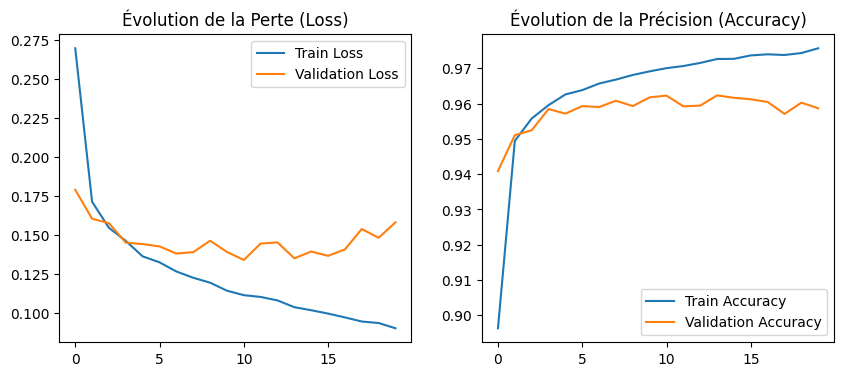

In [15]:

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

# Lancement de l'entraînement
print("\n--- Début de l'entraînement ---")
history = model.fit(
    X_train_pad, y_train,
    epochs=20,               
    batch_size=64,          
    validation_data=(X_val_pad, y_val)

)


# Tracer l'évolution de la Loss (Perte)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Évolution de la Perte (Loss)')
plt.legend()

# Tracer l'évolution de l'Accuracy (Précision)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Évolution de la Précision (Accuracy)')
plt.legend()
plt.show()


--- Évaluation sur le Test Set ---
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step

RAPPORT DE CLASSIFICATION :
                 precision    recall  f1-score   support

Particulier (0)       0.95      0.99      0.97     11871
 Entreprise (1)       0.97      0.91      0.94      6195

       accuracy                           0.96     18066
      macro avg       0.96      0.95      0.95     18066
   weighted avg       0.96      0.96      0.96     18066

Score ROC-AUC : 0.9788


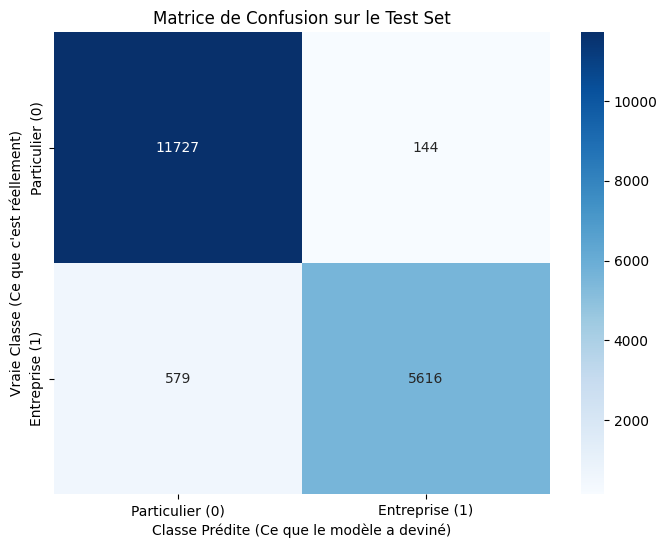


--- Analyse de quelques erreurs (Faux Positifs / Faux Négatifs) ---
Nom nettoyé: 'PC YEGHLA MOHAMMED CHAFIK' | Vraie: Entreprise | Prédite: Particulier (Proba: 0.01)
Nom nettoyé: 'AGENCE IMOBILIERE' | Vraie: Particulier | Prédite: Entreprise (Proba: 0.99)
Nom nettoyé: 'IHADDADENE' | Vraie: Entreprise | Prédite: Particulier (Proba: 0.06)
Nom nettoyé: 'MOUSSA OMAR' | Vraie: Entreprise | Prédite: Particulier (Proba: 0.01)
Nom nettoyé: 'HECHAICHI' | Vraie: Entreprise | Prédite: Particulier (Proba: 0.50)


In [17]:


# -------------------------------------------------------------------
# 1. Prédictions sur le Test Set
# -------------------------------------------------------------------
print("\n--- Évaluation sur le Test Set ---")
# Le modèle sort une probabilité entre 0 et 1 (grâce à la Sigmoid)
y_pred_prob = model.predict(X_test_pad)

# On transforme la probabilité en classe binaire (Seuil à 0.5)
# Si proba > 0.5 -> 1 (Entreprise), sinon -> 0 (Particulier)
y_pred = (y_pred_prob > 0.5).astype(int)

# -------------------------------------------------------------------
# 2. Le Rapport de Classification (Précision, Rappel, F1-Score)
# -------------------------------------------------------------------
target_names = ['Particulier (0)', 'Entreprise (1)']
print("\nRAPPORT DE CLASSIFICATION :")
print(classification_report(y_test, y_pred, target_names=target_names))

# Calcul du ROC-AUC (métrique très appréciée en Data Science)
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"Score ROC-AUC : {roc_auc:.4f}")

# -------------------------------------------------------------------
# 3. Visualisation de la Matrice de Confusion
# -------------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title('Matrice de Confusion sur le Test Set')
plt.ylabel('Vraie Classe (Ce que c\'est réellement)')
plt.xlabel('Classe Prédite (Ce que le modèle a deviné)')
plt.show()

# -------------------------------------------------------------------
# 4. BONUS : Afficher quelques erreurs (Pour comprendre ce qui bloque)
# -------------------------------------------------------------------
print("\n--- Analyse de quelques erreurs (Faux Positifs / Faux Négatifs) ---")
# Trouver les index où la prédiction est fausse
errors = np.where(y_pred.flatten() != y_test)[0]

# Afficher 5 exemples d'erreurs
for i in errors[:5]:
    nom_original = X_test[i]
    vraie_classe = "Entreprise" if y_test[i] == 1 else "Particulier"
    pred_classe = "Entreprise" if y_pred[i][0] == 1 else "Particulier"
    proba = y_pred_prob[i][0]
    print(f"Nom nettoyé: '{nom_original}' | Vraie: {vraie_classe} | Prédite: {pred_classe} (Proba: {proba:.2f})")

## runing experiments on diverse architectures

la fonction suivante va me permettre de faire plusieurs modeles et tracker leurs performances facilement

In [ ]:

experiment_results = pd.DataFrame(columns=[
    'Experiment_Name', 'Training_Time (s)', 'Epochs_Run',
    'Train_Loss', 'Val_Loss', 'Train_Acc', 'Val_Acc',
    'Test_Acc', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_ROC_AUC'
])

def run_experiment(model_builder_func, experiment_name, epochs=20, batch_size=128):
    global experiment_results
    
    print(f"\n{'='*60}")
    print(f"🚀 Lancement de l'expérience : {experiment_name}")
    print(f"{'='*60}\n")
    
    # 1. Création et entraînement
    model = model_builder_func()
    early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
    
    start_time = time.time()
    history = model.fit(
        X_train_pad, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val_pad, y_val),
        callbacks=[early_stop],
        verbose=1 
    )
    training_time = round(time.time() - start_time, 2)
    epochs_run = len(history.epoch)
    
    # 2. Récupération des meilleures métriques (Early Stopping)
    best_epoch_index = np.argmin(history.history['val_loss'])
    train_loss = history.history['loss'][best_epoch_index]
    val_loss = history.history['val_loss'][best_epoch_index]
    train_acc = history.history['accuracy'][best_epoch_index]
    val_acc = history.history['val_accuracy'][best_epoch_index]
    
    # 3. Évaluation sur le Test Set
    y_pred_prob = model.predict(X_test_pad, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    test_acc = accuracy_score(y_test, y_pred)
    test_prec = precision_score(y_test, y_pred)
    test_rec = recall_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, y_pred_prob)
    
    # 4. Sauvegarde dans le DataFrame
    new_result = pd.DataFrame([{
        'Experiment_Name': experiment_name, 'Training_Time (s)': training_time, 'Epochs_Run': epochs_run,
        'Train_Loss': round(train_loss, 4), 'Val_Loss': round(val_loss, 4),
        'Train_Acc': round(train_acc, 4), 'Val_Acc': round(val_acc, 4),
        'Test_Acc': round(test_acc, 4), 'Test_Precision': round(test_prec, 4),
        'Test_Recall': round(test_rec, 4), 'Test_F1': round(test_f1, 4), 'Test_ROC_AUC': round(test_roc_auc, 4)
    }])
    experiment_results = pd.concat([experiment_results, new_result], ignore_index=True)
    

    # 5. AFFICHAGE VISUEL (Rapport & Graphes)
  
    target_names = ['Particulier (0)', 'Entreprise (1)']
    
    print(f"\n✅ Expérience terminée en {training_time}s ! Test F1-Score : {test_f1:.4f}")
    print("\n" + "-"*40)
    print("📋 RAPPORT DE CLASSIFICATION (Test Set) :")
    print("-"*40)
    print(classification_report(y_test, y_pred, target_names=target_names))
    
    # Création d'une figure avec 3 graphiques côte à côte (1 ligne, 3 colonnes)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Performances de l'architecture : {experiment_name}", fontsize=16, y=1.05)
    
    # Graphique 1 : Loss
    axes[0].plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
    axes[0].set_title('Évolution de la Perte (Loss)')
    axes[0].set_xlabel('Époques')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # Graphique 2 : Accuracy
    axes[1].plot(history.history['accuracy'], label='Train Acc', color='blue', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='orange', linewidth=2)
    axes[1].set_title('Évolution de la Précision (Accuracy)')
    axes[1].set_xlabel('Époques')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)
    
    # Graphique 3 : Matrice de Confusion
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], 
                xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 14})
    axes[2].set_title('Matrice de Confusion (Test Set)')
    axes[2].set_ylabel('Vraie Classe')
    axes[2].set_xlabel('Classe Prédite')
    
    plt.tight_layout()
    plt.show()
    
    return model

###  Historique des Architectures Expérimentées

*   **CNN_Base_Dim16_Filters128 :** `Conv1D` classique (Dim=16, 128 filtres, Kernel=4) avec un GlobalMaxPool et une couche Dense(64) régularisée (Dropout 0.5).
*   **CNN_Light_Dim8_Filters128 :** Réduction de l'Embedding (Dim=8) pour alléger le modèle, en conservant 128 filtres de convolution.
*   **Bi-LSTM_Dim16 :** Approche récurrente utilisant un `Bidirectional LSTM` (32 unités) pour lire la séquence de caractères dans les deux sens.
*   **CNN_2D_Filtres32-64_Dim16 :** Astuce visuelle via `Reshape` transformant l'Embedding en espace 2D, suivi de deux `Conv2D` (32 puis 64 filtres, Kernel 3x3) et MaxPooling2D.
*   **CNN_maxpool1D_kernel2_Dim8_Filters64 :** `Conv1D` très léger (Dim=8, 64 filtres, Kernel court=2) avec un MaxPooling classique et double couche Dense(32) sans Dropout.
*   **CNN_kernel2_nodropout_dense_64_Dim8_Filters64 :** Similaire au précédent mais utilisant un GlobalMaxPool et un double Dense(64), assumant l'absence totale de Dropout.
*   **CNN_Base_Dim32_Filters128 :** Augmentation forte de la taille du plongement lexical (Dim=32) avec la base `Conv1D` à 128 filtres.
*   **CNN_Base_Dim22_Filters128 :** Compromis sur l'Embedding (Dim=22) pour tester l'impact dimensionnel sur l'overfitting.
*   **CNN_Base_Dim16_Filters32 :** Réduction du nombre de filtres `Conv1D` (32 filtres) compensée par un réseau Dense plus profond (deux couches 64) avec un Dropout léger (0.3).
*   **CNN_2D_Filtres64_Dim16_v2 :** Version modifiée de l'architecture 2D avec des filtres plus nombreux (64) dès la première couche et des fenêtres de convolution plus petites (Kernel 2x2).


🚀 Lancement de l'expérience : CNN_Base_Dim16_Filters128

Epoch 1/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9020 - loss: 0.2625 - val_accuracy: 0.9416 - val_loss: 0.1811
Epoch 2/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9489 - loss: 0.1690 - val_accuracy: 0.9511 - val_loss: 0.1569
Epoch 3/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9562 - loss: 0.1529 - val_accuracy: 0.9525 - val_loss: 0.1578
Epoch 4/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9602 - loss: 0.1427 - val_accuracy: 0.9582 - val_loss: 0.1445
Epoch 5/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9634 - loss: 0.1345 - val_accuracy: 0.9582 - val_loss: 0.1444
Epoch 6/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9650 - loss: 0.1303 - val_accuracy: 0.9599 - val_loss: 0.1458
Epoch 7/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9665 - loss: 0.1255 - val_accuracy: 0.9587 - val_loss: 0.1457
Epoch 8/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms

C:\Users\darkf\AppData\Local\Temp\ipykernel_27120\293907678.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  experiment_results = pd.concat([experiment_results, new_result], ignore_index=True)



✅ Expérience terminée en 51.25s ! Test F1-Score : 0.9479

----------------------------------------
📋 RAPPORT DE CLASSIFICATION (Test Set) :
----------------------------------------
                 precision    recall  f1-score   support

Particulier (0)       0.97      0.98      0.97     11871
 Entreprise (1)       0.96      0.93      0.95      6195

       accuracy                           0.96     18066
      macro avg       0.96      0.96      0.96     18066
   weighted avg       0.96      0.96      0.96     18066



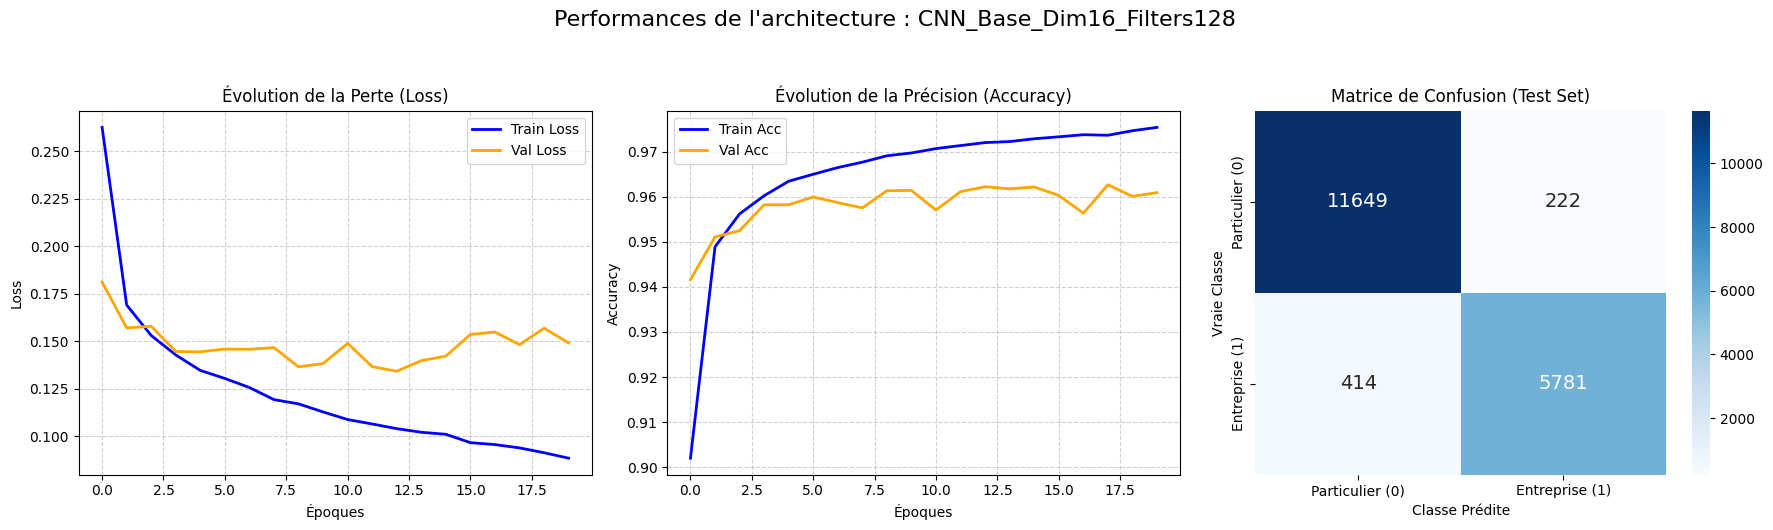

In [ ]:

def build_cnn_base():
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=16))
    model.add(Conv1D(filters=128, kernel_size=4, activation='relu'))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


model_v1 = run_experiment(build_cnn_base, "CNN_Base_Dim16_Filters128", epochs=50, batch_size=64)


🚀 Lancement de l'expérience : CNN_Light_Dim8_Filters128

Epoch 1/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8834 - loss: 0.2950 - val_accuracy: 0.9356 - val_loss: 0.1948
Epoch 2/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9440 - loss: 0.1837 - val_accuracy: 0.9469 - val_loss: 0.1720
Epoch 3/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9512 - loss: 0.1641 - val_accuracy: 0.9524 - val_loss: 0.1576
Epoch 4/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9556 - loss: 0.1560 - val_accuracy: 0.9521 - val_loss: 0.1574
Epoch 5/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9582 - loss: 0.1494 - val_accuracy: 0.9524 - val_loss: 0.1572
Epoch 6/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9602 - loss: 0.1463 - val_accuracy: 0.9545 - val_loss: 0.1550
Epoch 7/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9606 - loss: 0.1433 - val_accuracy: 0.9533 - val_loss: 0.1495
Epoch 8/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms

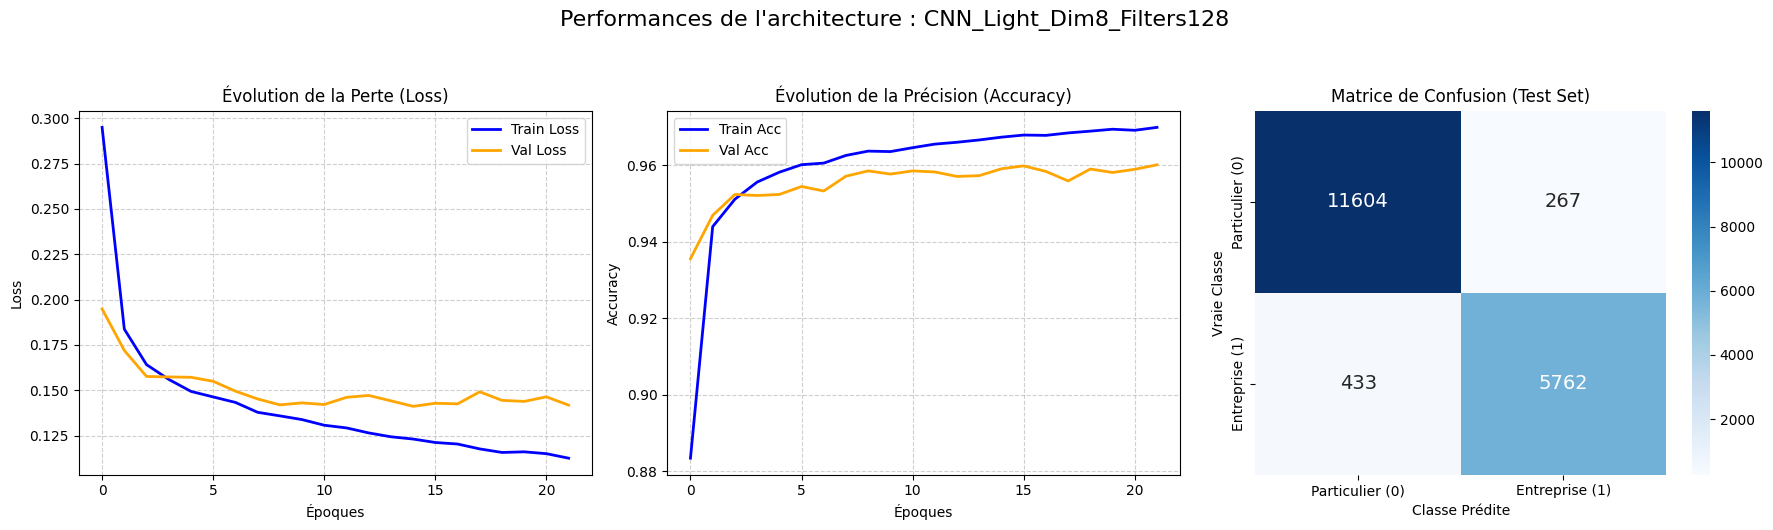

In [ ]:
def build_cnn_light():
    model = Sequential()
    # On réduit l'embedding à 8 et les filtres à 64
    model.add(Embedding(input_dim=vocab_size, output_dim=8))
    model.add(Conv1D(filters=128, kernel_size=4, activation='relu')) # Kernel plus petit
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5)) # Moins de dropout
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


model_v2 = run_experiment(build_cnn_light, "CNN_Light_Dim8_Filters128", epochs=50, batch_size=64)


🚀 Lancement de l'expérience : Bi-LSTM_Dim16

Epoch 1/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8888 - loss: 0.2920 - val_accuracy: 0.9260 - val_loss: 0.2148
Epoch 2/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9298 - loss: 0.2191 - val_accuracy: 0.9297 - val_loss: 0.2041
Epoch 3/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9345 - loss: 0.2070 - val_accuracy: 0.9377 - val_loss: 0.1902
Epoch 4/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9400 - loss: 0.1935 - val_accuracy: 0.9403 - val_loss: 0.1793
Epoch 5/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9449 - loss: 0.1820 - val_accuracy: 0.9395 - val_loss: 0.1822
Epoch 6/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9483 - loss: 0.1734 - val_accuracy: 0.9478 - val_loss: 0.1632
Epoch 7/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9511 - loss: 0.1668 - val_accuracy: 0.9469 - val_loss: 0.1667
Epoch 8/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc

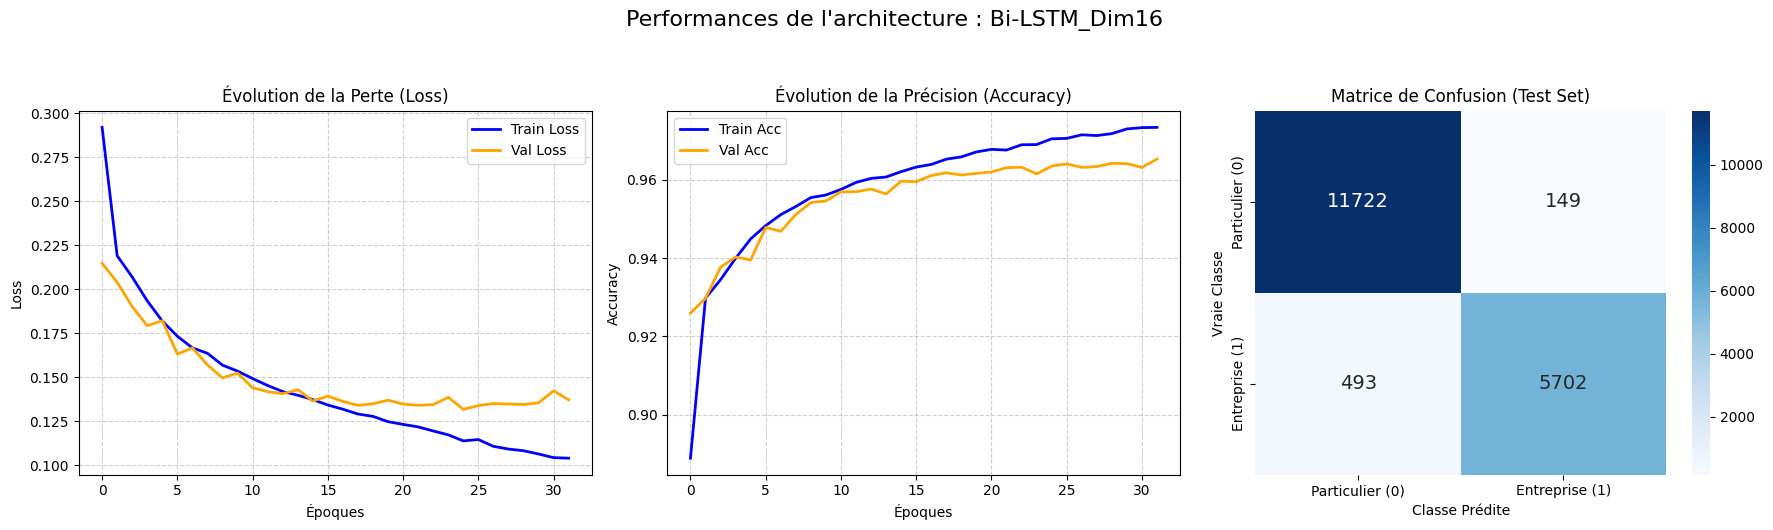

In [ ]:


def build_bilstm():
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=16))
    # Le LSTM lit la séquence de caractères de gauche à droite ET de droite à gauche
    model.add(Bidirectional(LSTM(32))) 
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_v3 = run_experiment(build_bilstm, "Bi-LSTM_Dim16", epochs=50, batch_size=64)


🚀 Lancement de l'expérience : CNN_2D_Filtres32-64_Dim16

Epoch 1/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8557 - loss: 0.3566 - val_accuracy: 0.9062 - val_loss: 0.2559
Epoch 2/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9313 - loss: 0.2223 - val_accuracy: 0.9225 - val_loss: 0.2279
Epoch 3/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9431 - loss: 0.1950 - val_accuracy: 0.9424 - val_loss: 0.1843
Epoch 4/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9491 - loss: 0.1804 - val_accuracy: 0.9494 - val_loss: 0.1675
Epoch 5/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9527 - loss: 0.1693 - val_accuracy: 0.9501 - val_loss: 0.1703
Epoch 6/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9553 - loss: 0.1608 - val_accuracy: 0.9526 - val_loss: 0.1588
Epoch 7/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9572 - loss: 0.1556 - val_accuracy: 0.9530 - val_loss: 0.1570
Epoch 8/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms

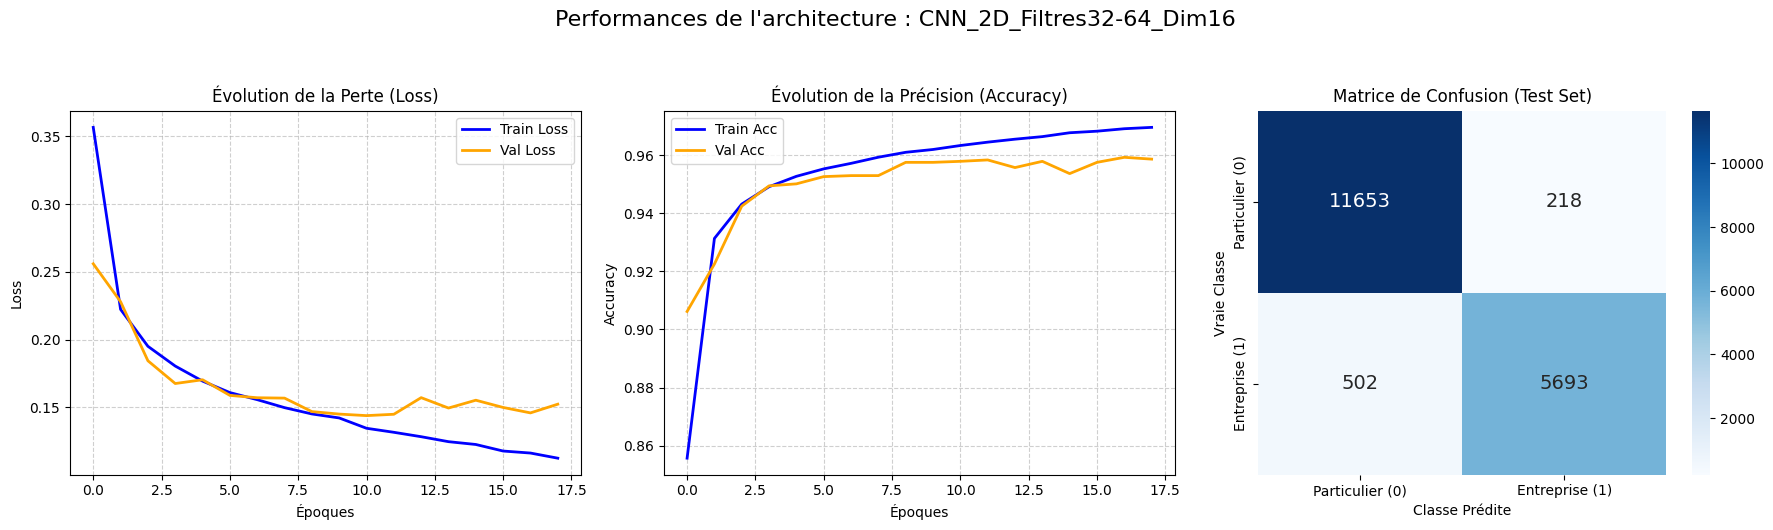

In [ ]:
def build_cnn_2d_model():
    model = Sequential()
    

    model.add(Embedding(input_dim=vocab_size, output_dim=16))
    

    model.add(Reshape((MAX_SEQ_LENGTH, 16, 1)))
    

    model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
 
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
  
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
    
    model.add(GlobalMaxPooling2D())
    

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model


model_2d = run_experiment(build_cnn_2d_model, "CNN_2D_Filtres32-64_Dim16", epochs=50, batch_size=64)


🚀 Lancement de l'expérience : CNN_maxpool1D_kernel2_Dim8_Filters64

Epoch 1/50


c:\Users\darkf\OneDrive\Desktop\coding_work\mon_enviro\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9047 - loss: 0.2517 - val_accuracy: 0.9348 - val_loss: 0.1994
Epoch 2/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9370 - loss: 0.1883 - val_accuracy: 0.9388 - val_loss: 0.1913
Epoch 3/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9438 - loss: 0.1718 - val_accuracy: 0.9431 - val_loss: 0.1785
Epoch 4/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9481 - loss: 0.1611 - val_accuracy: 0.9490 - val_loss: 0.1662
Epoch 5/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9528 - loss: 0.1515 - val_accuracy: 0.9471 - val_loss: 0.1718
Epoch 6/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9555 - loss: 0.1442 - val_accuracy: 0.9540 - val_loss: 0.1551
Epoch 7/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9584 - loss: 0.1380 - val_accuracy: 0.9532 - val_loss: 0.1531
Epoch 8/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9604 - loss: 0.1320 - val_accuracy: 0.9531 - val_

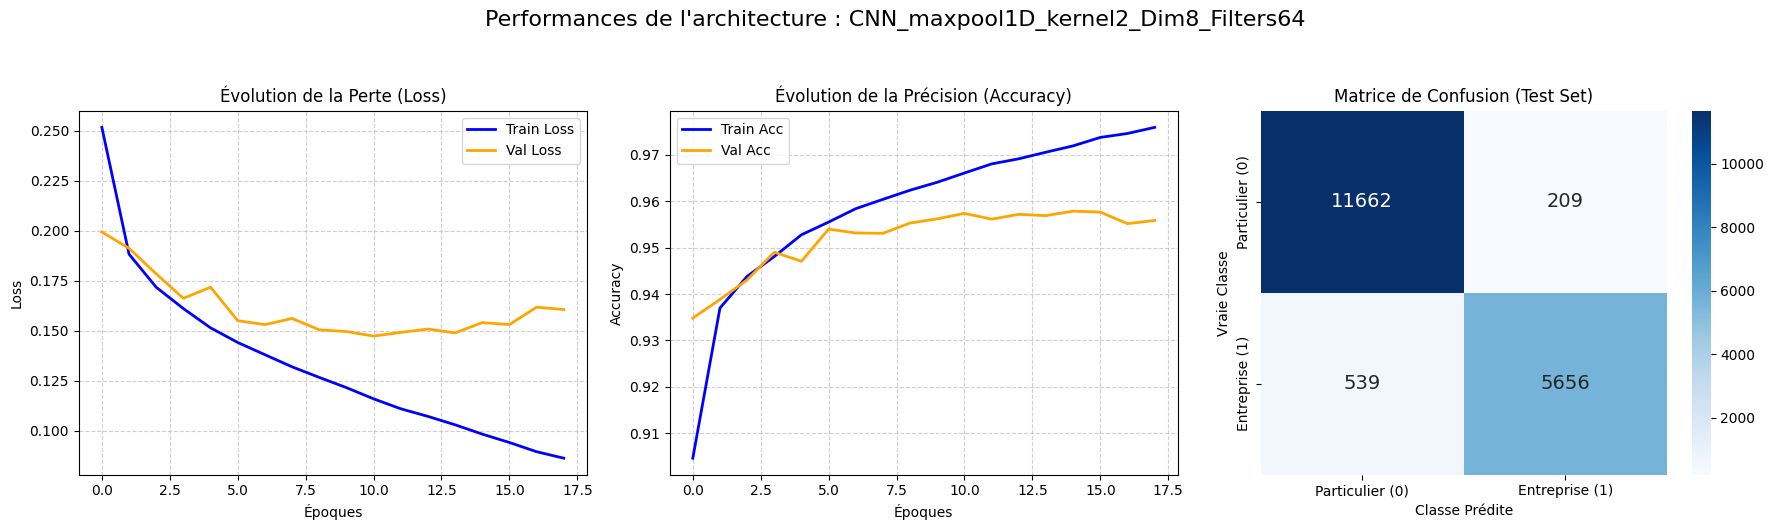

In [ ]:
def build_cnn_light_v2():
    model = Sequential()
    # On réduit l'embedding à 8 et les filtres à 64
    model.add(Embedding(input_dim=vocab_size, output_dim=8, input_length=MAX_SEQ_LENGTH))
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu'))  # Kernel plus petit
    model.add(MaxPooling1D(pool_size=2))  # Changed from GlobalMaxPooling1D to MaxPooling1D with pool_size=2
    model.add(Flatten())  # Added to flatten the 3D output to 2D for Dense layers
    model.add(Dense(32, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


model_cnn_v2 = run_experiment(build_cnn_light_v2, "CNN_maxpool1D_kernel2_Dim8_Filters64", epochs=50, batch_size=64)


🚀 Lancement de l'expérience : CNN_kernel2_nodropout_dense_64_Dim8_Filters64

Epoch 1/50


c:\Users\darkf\OneDrive\Desktop\coding_work\mon_enviro\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8892 - loss: 0.2781 - val_accuracy: 0.9249 - val_loss: 0.2186
Epoch 2/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9355 - loss: 0.1942 - val_accuracy: 0.9401 - val_loss: 0.1863
Epoch 3/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9408 - loss: 0.1823 - val_accuracy: 0.9437 - val_loss: 0.1777
Epoch 4/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9442 - loss: 0.1741 - val_accuracy: 0.9422 - val_loss: 0.1788
Epoch 5/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9464 - loss: 0.1699 - val_accuracy: 0.9442 - val_loss: 0.1758
Epoch 6/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9482 - loss: 0.1665 - val_accuracy: 0.9469 - val_loss: 0.1683
Epoch 7/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9476 - loss: 0.1653 - val_accuracy: 0.9499 - val_loss: 0.1661
Epoch 8/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9491 - loss: 0.1617 - val_accuracy: 0.9478 - val_

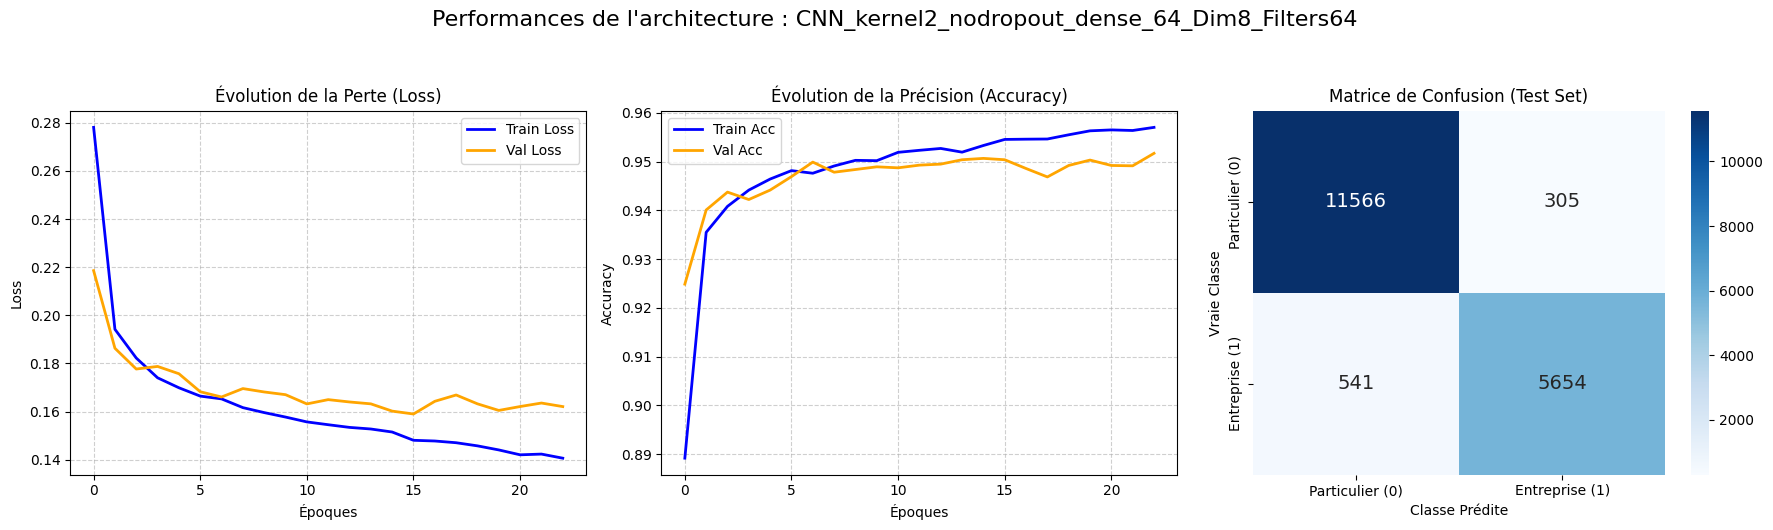

In [ ]:
def build_cnn_light_v3():
    model = Sequential()
    # On réduit l'embedding à 8 et les filtres à 64
    model.add(Embedding(input_dim=vocab_size, output_dim=8, input_length=MAX_SEQ_LENGTH))
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu')) # Kernel plus petit
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


model_cnn_v3 = run_experiment(build_cnn_light_v3, "CNN_kernel2_nodropout_dense_64_Dim8_Filters64", epochs=50, batch_size=64)


🚀 Lancement de l'expérience : CNN_Base_Dim32_Filters128

Epoch 1/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9112 - loss: 0.2412 - val_accuracy: 0.9467 - val_loss: 0.1816
Epoch 2/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9545 - loss: 0.1594 - val_accuracy: 0.9541 - val_loss: 0.1527
Epoch 3/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9601 - loss: 0.1460 - val_accuracy: 0.9593 - val_loss: 0.1443
Epoch 4/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9626 - loss: 0.1353 - val_accuracy: 0.9610 - val_loss: 0.1368
Epoch 5/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9657 - loss: 0.1282 - val_accuracy: 0.9624 - val_loss: 0.1349
Epoch 6/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9666 - loss: 0.1240 - val_accuracy: 0.9618 - val_loss: 0.1332
Epoch 7/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9678 - loss: 0.1187 - val_accuracy: 0.9633 - val_loss: 0.1328
Epoch 8/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms

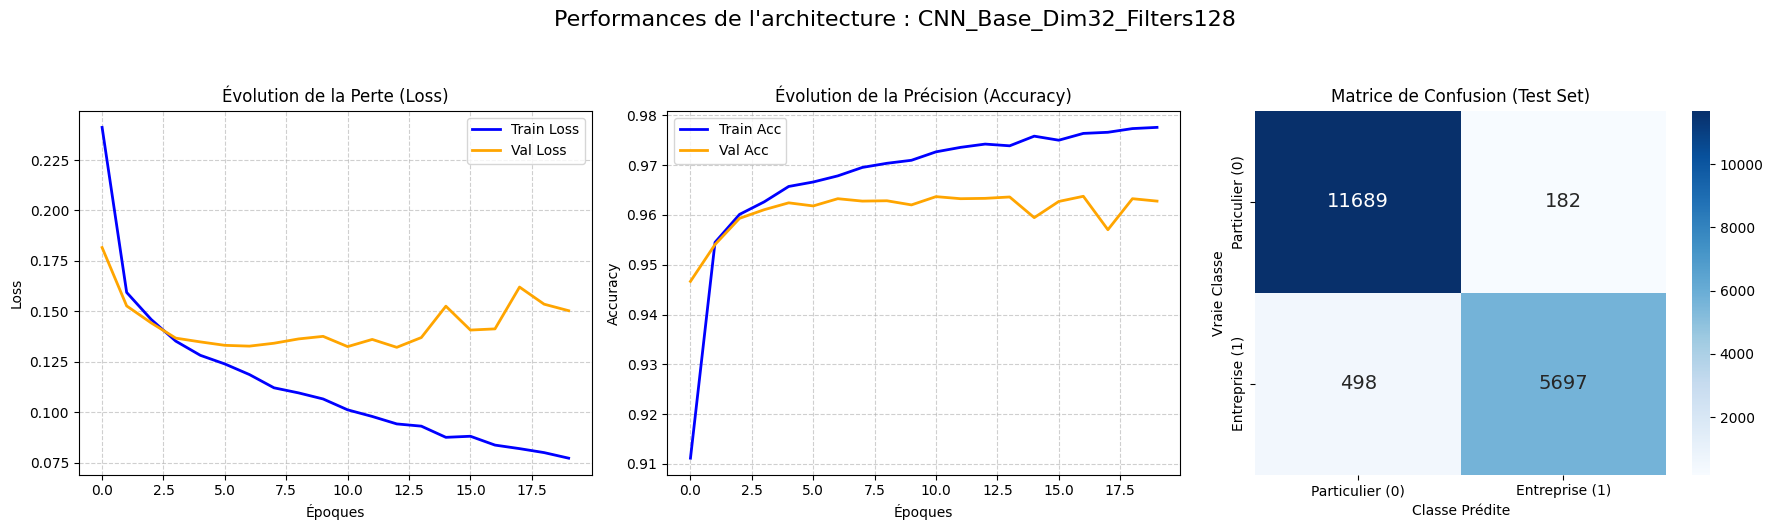

In [ ]:

def build_cnn_base_Dim32():
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=32))
    model.add(Conv1D(filters=128, kernel_size=4, activation='relu'))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_v4 = run_experiment(build_cnn_base_Dim32, "CNN_Base_Dim32_Filters128", epochs=50, batch_size=64)


🚀 Lancement de l'expérience : CNN_Base_Dim22_Filters128

Epoch 1/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9072 - loss: 0.2524 - val_accuracy: 0.9486 - val_loss: 0.1690
Epoch 2/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9528 - loss: 0.1625 - val_accuracy: 0.9477 - val_loss: 0.1706
Epoch 3/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9591 - loss: 0.1492 - val_accuracy: 0.9601 - val_loss: 0.1432
Epoch 4/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9617 - loss: 0.1398 - val_accuracy: 0.9595 - val_loss: 0.1448
Epoch 5/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9641 - loss: 0.1339 - val_accuracy: 0.9596 - val_loss: 0.1465
Epoch 6/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9657 - loss: 0.1272 - val_accuracy: 0.9608 - val_loss: 0.1376
Epoch 7/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9679 - loss: 0.1216 - val_accuracy: 0.9604 - val_loss: 0.1385
Epoch 8/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms

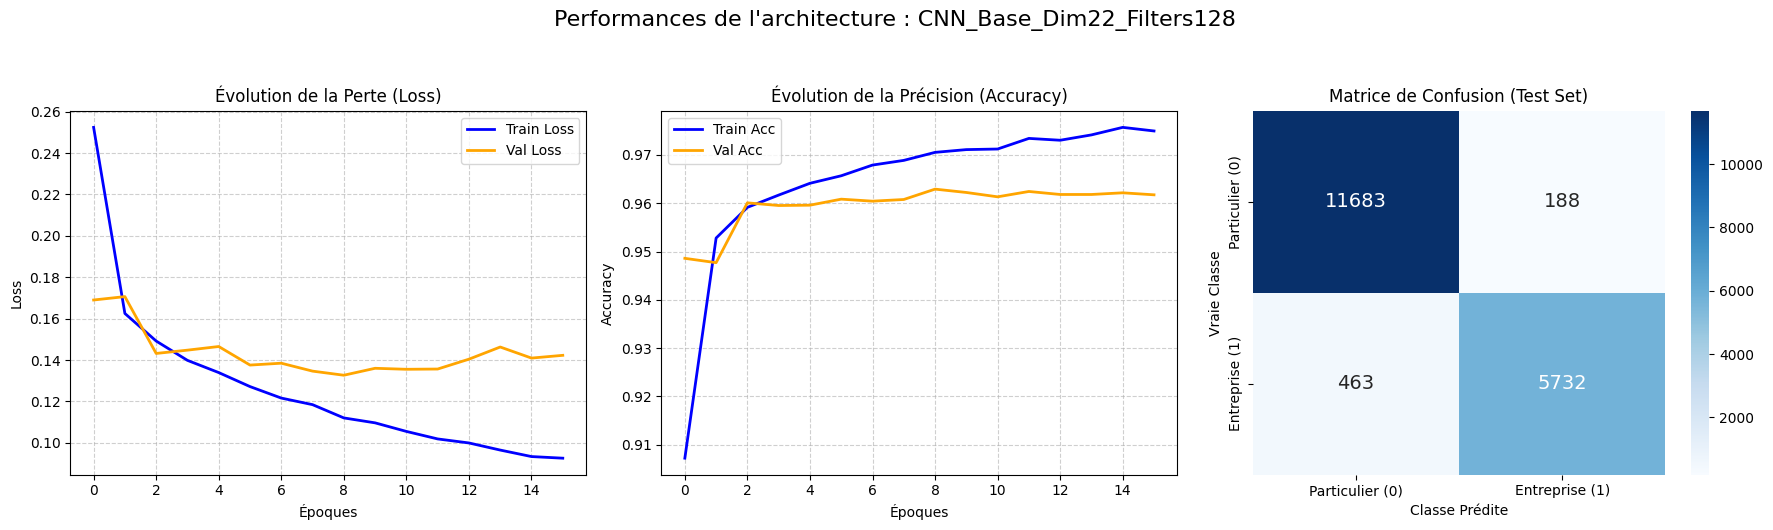

In [ ]:

def build_cnn_base_Dim22():
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=22))
    model.add(Conv1D(filters=128, kernel_size=4, activation='relu'))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_v5 = run_experiment(build_cnn_base_Dim22, "CNN_Base_Dim22_Filters128", epochs=50, batch_size=64)


🚀 Lancement de l'expérience : CNN_Base_Dim16_Filters32

Epoch 1/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8964 - loss: 0.2683 - val_accuracy: 0.9411 - val_loss: 0.1856
Epoch 2/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9446 - loss: 0.1793 - val_accuracy: 0.9485 - val_loss: 0.1680
Epoch 3/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9507 - loss: 0.1647 - val_accuracy: 0.9496 - val_loss: 0.1639
Epoch 4/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9541 - loss: 0.1570 - val_accuracy: 0.9514 - val_loss: 0.1607
Epoch 5/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9560 - loss: 0.1515 - val_accuracy: 0.9518 - val_loss: 0.1557
Epoch 6/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9571 - loss: 0.1482 - val_accuracy: 0.9532 - val_loss: 0.1558
Epoch 7/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9596 - loss: 0.1435 - val_accuracy: 0.9525 - val_loss: 0.1556
Epoch 8/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/

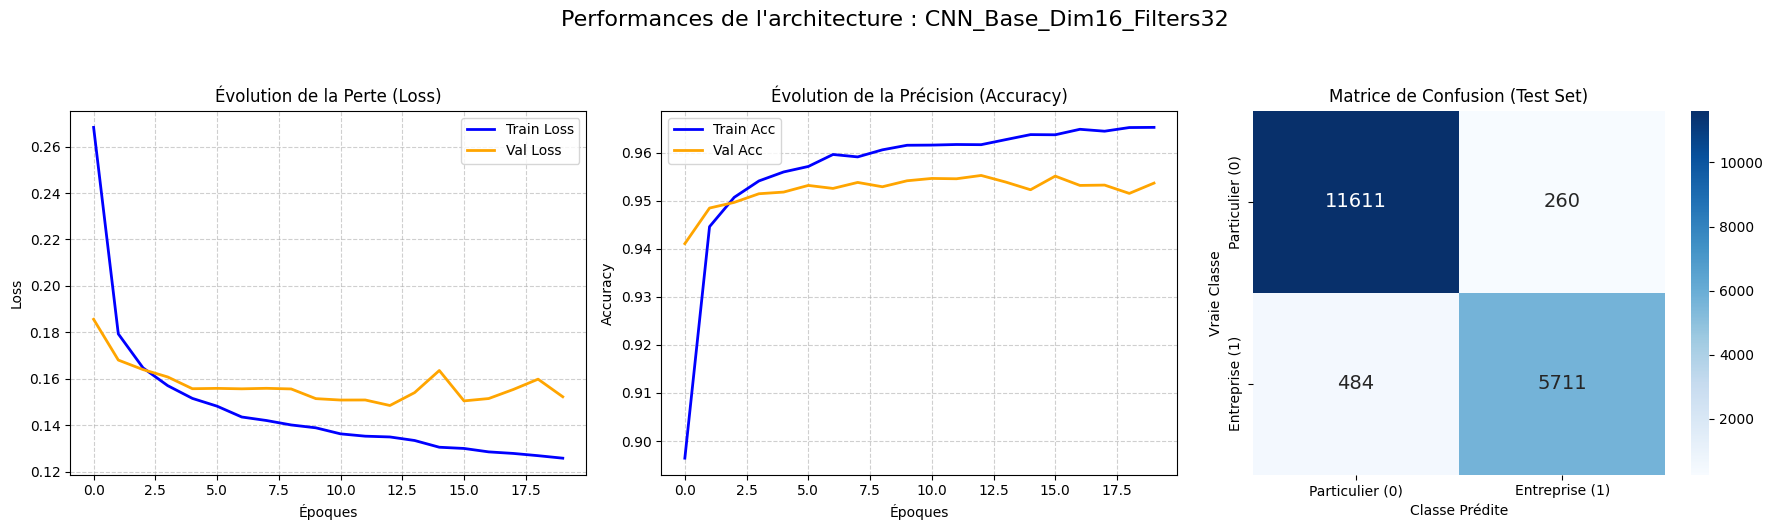

In [ ]:
def build_cnn_base_Dim16_filter32():
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=16))
    model.add(Conv1D(filters=32, kernel_size=4, activation='relu'))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))    
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_v6 = run_experiment(build_cnn_base_Dim16_filter32, "CNN_Base_Dim16_Filters32", epochs=50, batch_size=64)


🚀 Lancement de l'expérience : CNN_2D_Filtres64_Dim16_v2

Epoch 1/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8176 - loss: 0.4205 - val_accuracy: 0.8941 - val_loss: 0.2826
Epoch 2/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9195 - loss: 0.2462 - val_accuracy: 0.9060 - val_loss: 0.2584
Epoch 3/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9350 - loss: 0.2115 - val_accuracy: 0.9386 - val_loss: 0.1884
Epoch 4/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9431 - loss: 0.1921 - val_accuracy: 0.9442 - val_loss: 0.1798
Epoch 5/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9461 - loss: 0.1847 - val_accuracy: 0.9442 - val_loss: 0.1796
Epoch 6/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9494 - loss: 0.1769 - val_accuracy: 0.9498 - val_loss: 0.1674
Epoch 7/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9504 - loss: 0.1736 - val_accuracy: 0.9518 - val_loss: 0.1632
Epoch 8/50
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms

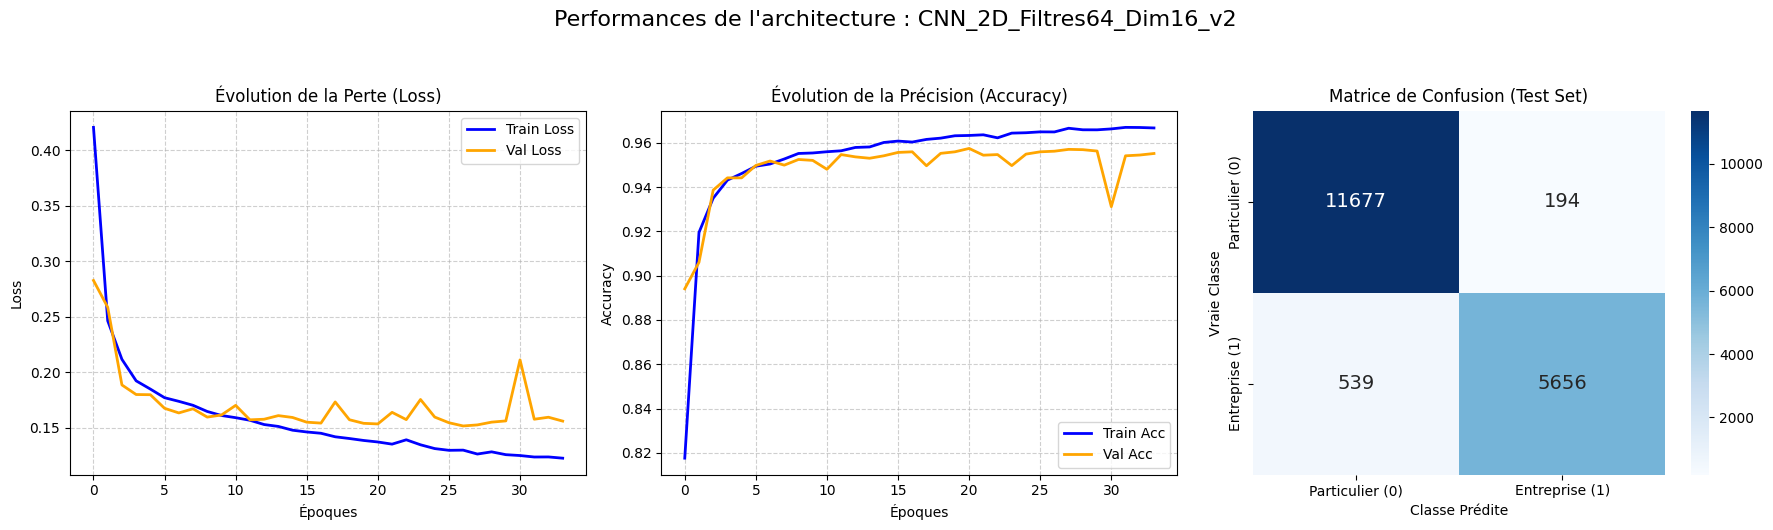

In [ ]:
def build_cnn_2d_model_v2():
    model = Sequential()
    

    model.add(Embedding(input_dim=vocab_size, output_dim=16))
    

    model.add(Reshape((MAX_SEQ_LENGTH, 16, 1)))
    

    model.add(Conv2D(filters=64, kernel_size=(2, 2), activation='relu'))
 
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
  
    model.add(Conv2D(filters=64, kernel_size=(2, 2), activation='relu'))
    
    model.add(GlobalMaxPooling2D())
    

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model


model_2d_v2 = run_experiment(build_cnn_2d_model_v2, "CNN_2D_Filtres64_Dim16_v2", epochs=50, batch_size=64)

In [82]:
# Afficher le tableau de bord, trié par le meilleur F1-Score sur le Test set
display(experiment_results.sort_values(by='Test_F1', ascending=False))

,Experiment_Name,Training_Time (s),Epochs_Run,Train_Loss,Val_Loss,Train_Acc,Val_Acc,Test_Acc,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,CNN_Base_Dim16_Filters128,51.25,20,0.1039,0.1341,0.9720,0.9622,0.9648,0.9630,0.9332,0.9479,0.9787
2,Bi-LSTM_Dim16,234.37,32,0.1139,0.1318,0.9705,0.9635,0.9645,0.9745,0.9204,0.9467,0.9786
7,CNN_Base_Dim22_Filters128,52.82,16,0.1120,0.1327,0.9705,0.9629,0.9640,0.9682,0.9253,0.9463,0.9783
6,CNN_Base_Dim32_Filters128,74.52,20,0.0943,0.1322,0.9742,0.9633,0.9624,0.9690,0.9196,0.9437,0.9783
1,CNN_Light_Dim8_Filters128,59.22,22,0.1231,0.1411,0.9674,0.9591,0.9613,0.9557,0.9301,0.9427,0.9775
3,CNN_2D_Filtres32-64_Dim16,106.73,18,0.1345,0.1438,0.9633,0.9579,0.9601,0.9631,0.9190,0.9405,0.9766
9,CNN_2D_Filtres64_Dim16_v2,230.89,34,0.1297,0.1514,0.9649,0.9562,0.9594,0.9668,0.9130,0.9391,0.9764
8,CNN_Base_Dim16_Filters32,43.96,20,0.1349,0.1485,0.9616,0.9552,0.9588,0.9565,0.9219,0.9388,0.9756
4,CNN_maxpool1D_kernel2_Dim8_Filters64,49.16,18,0.1160,0.1474,0.9661,0.9574,0.9586,0.9644,0.9130,0.9380,0.9745
5,CNN_kernel2_nodropout_dense_64_Dim8_Filters64,65.03,23,0.1481,0.1590,0.9546,0.9504,0.9532,0.9488,0.9127,0.9304,0.9733


###  Synthèse des Expérimentations et Sélection du Modèle Final

En analysant le tableau récapitulatif `experiment_results`, on observe que les métriques de performance globales sont très proches entre les différentes architectures testées (char-cnn Conv1D, BI-LSTM, char-cnn Conv2D). 

Cependant, l'analyse approfondie des courbes d'apprentissage (*Learning Curves*) a permis de les départager. Le critère décisif de sélection a été la capacité du modèle à **généraliser sur de nouvelles données tout en minimisant le surapprentissage (Overfitting)**.

À l'issue de cette analyse, l'architecture retenue est le **`CNN_2D_Filtres32-64_Dim16`**. Basé sur Char-CNN, la transformation de la matrice d'Embedding en espace 2D couplée au MaxPooling a prouvé sa grande robustesse sur nos données bruitées.

####  Performances sur le Test Set (Données jamais vues) :
*  **Accuracy** : `96.01%` 
*  **F1-Score** : `94.05%` 

####  Architecture du Modèle Retenu :
```python
    model = Sequential()

    model.add(Embedding(input_dim=vocab_size, output_dim=16))
  
    model.add(Reshape((MAX_SEQ_LENGTH, 16, 1)))

    model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))

    model.add(GlobalMaxPooling2D())

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    


## Test de mon modele

j'ai demandé à l'ia de me generer des nom afin de tester la precision de mon modele

In [ ]:
# 1. Génération de nos nouvelles données "brutes" de production

nouveaux_clients = [

    "Mr Yassine Berrabah",           
    "Mme Samira Kaddour",            
    "Amine Djedidi",                 
    

    "SARL MENUISERIE EL AMAN",                
    "EURL GLOBALE LOGISTIQUE IMPORT EXPORT",   
    "BUREAU D ETUDES ARCHITECTURE ZITOUNI"     
]

# 2. La Pipeline de Pré-traitement (Exactement comme pour l'entraînement)

def clean_new_name(name):
    name = str(name).upper()
    words_to_remove = [r'\bSARL\b', r'\bEURL\b', r'\bMR\b', r'\bMME\b', r'\bMONSIEUR\b', r'\bMADAME\b']
    for word in words_to_remove:
        name = re.sub(word, '', name)
    name = re.sub(r'[^A-Z0-9\s]', ' ', name) # on garde que les lettres, chiffres et espaces comme dans mon vocab dict
    name = re.sub(r'\s+', ' ', name).strip()
    return name

# Application du nettoyage
noms_nettoyes = [clean_new_name(nom) for nom in nouveaux_clients]

# Tokenization (au niveau caractère) et Padding
# ATTENTION : On utilise le 'tokenizer' qui a déjà été fitté (entraîné) précédemment !
seq = tokenizer.texts_to_sequences(noms_nettoyes)
seq_pad = pad_sequences(seq, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')

# 3. Prédiction avec le meilleur modèle (Le char-CNN 2D)

predictions_proba = model_2d.predict(seq_pad, verbose=0)


print("\n" + "="*70)
print(" TEST EN PRODUCTION : CLASSIFICATION DES NOUVEAUX ASSURÉS")
print("="*70 + "\n")

for i in range(len(nouveaux_clients)):
    nom_brut = nouveaux_clients[i]
    nom_clean = noms_nettoyes[i]
    proba_entreprise = predictions_proba[i][0]
    
    # Règle de décision : Seuil à 0.5
    if proba_entreprise > 0.5:
        classe_predite = "ENTREPRISE"
        confiance = proba_entreprise * 100
    else:
        classe_predite = "PARTICULIER"
        confiance = (1 - proba_entreprise) * 100
        
    print(f"Saisie Agent   : {nom_brut}")
    print(f"Vu par l'I.A.  : '{nom_clean}'")
    print(f"Prédiction     : {classe_predite} (Confiance : {confiance:.1f}%)")
    print("-" * 70)


🚀 TEST EN PRODUCTION : CLASSIFICATION DES NOUVEAUX ASSURÉS

Saisie Agent   : Mr Yassine Berrabah
Vu par l'I.A.  : 'YASSINE BERRABAH'
Prédiction     : ENTREPRISE (Confiance : 56.2%)
----------------------------------------------------------------------
Saisie Agent   : Mme Samira Kaddour
Vu par l'I.A.  : 'SAMIRA KADDOUR'
Prédiction     : PARTICULIER (Confiance : 99.0%)
----------------------------------------------------------------------
Saisie Agent   : Amine Djedidi
Vu par l'I.A.  : 'AMINE DJEDIDI'
Prédiction     : PARTICULIER (Confiance : 97.5%)
----------------------------------------------------------------------
Saisie Agent   : SARL MENUISERIE EL AMAN
Vu par l'I.A.  : 'MENUISERIE EL AMAN'
Prédiction     : ENTREPRISE (Confiance : 93.2%)
----------------------------------------------------------------------
Saisie Agent   : EURL GLOBALE LOGISTIQUE IMPORT EXPORT
Vu par l'I.A.  : 'GLOBALE LOGISTIQUE IMPORT EXPORT'
Prédiction     : ENTREPRISE (Confiance : 99.4%)
--------------------

In [91]:
# Sauvegarder tout le modèle (architecture + poids + config optimizer)
model_2d.save('mon_modele_2d.keras') 

In [86]:
model_2d.summary()

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_32 (Embedding)        │ (None, 30, 16)         │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 30, 16, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 5, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_3          │ (None, 64)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,661 (252.59 KB)

 Trainable params: 21,553 (84.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 43,108 (168.39 KB)